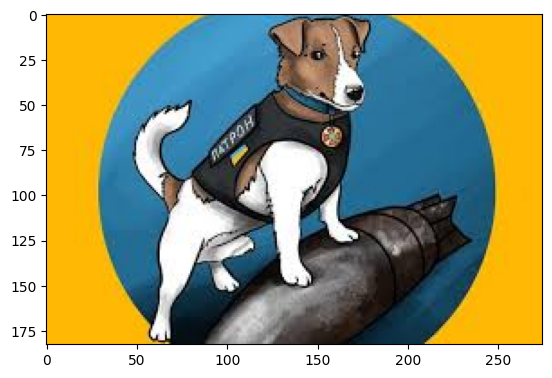

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
from scipy.linalg import solve

img = plt.imread('pes.jpg')
plt.imshow(img)

# Псування пса Патрона

In [2]:
def destroy_pixels(img, percent):
    # Копіюємо зображення, щоб не змінювати оригінал
    corrupted_img = img.copy()

    # Обчислюємо кількість пікселів, які треба знищити
    total_pixels = img.shape[0] * img.shape[1]
    pixels_to_destroy = int(total_pixels * percent / 100)

    # Генеруємо випадкові координати пікселів, які будуть занулені
    rows = np.random.randint(0, img.shape[0], pixels_to_destroy)
    cols = np.random.randint(0, img.shape[1], pixels_to_destroy)

    for r, c in zip(rows, cols):
        corrupted_img[r, c] = 0  # Обнулити значення (всі канали кольору)

    return corrupted_img

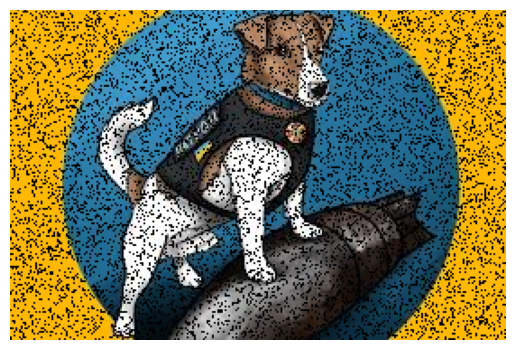

In [3]:
corrupted = destroy_pixels(img, percent=20)  # Знищити 20% пікселів
plt.imshow(corrupted)
plt.axis('off')
plt.show()

In [4]:
img.shape

(183, 275, 3)

# Реабілітація пса Патрона

In [5]:
# from scipy.linalg import solve
#
# # Coefficient matrix A
# A = np.array([[3, 1],
#               [1, 2]])
#
# # Right-hand side vector b
# b = np.array([9, 8])
#
# # Solve for x
# x = solve(A, b)
#
# print("Solution:", x)

In [6]:
# from sympy import symbols, Eq, solve

# # Declare variables
# x, y = symbols('x y')

# # Define equations
# eq1 = Eq(3*x + y, 9)
# eq2 = Eq(x + 2*y, 8)

# # Solve the system
# solution = solve((eq1, eq2), (x, y))

# print("Solution:", solution)

### Функції та змінні для зручності

In [7]:
def is_corrupted(pixel):
    corrupted_pixel = [0,0,0]
    return np.all(pixel == corrupted_pixel)

### Створення системи лінійних рівнянь

Отримання сусідніх елементів

In [8]:
def get_neighbours(img, col, row):
    colN, rowN, _ = img.shape
    if (col >=colN or col < 0
     or row >= rowN or row < 0):
        raise Exception(f"Wrong (row, column): {(row, col)}")
    return [(col + i, row + j)
     for i in [-1, 0, 1]
      for j in [-1, 0, 1]
       if 0 <= col + i < colN
        and 0 <= row + j < rowN
         and not i == j == 0]

# testing
print(get_neighbours(img, 0, 1))
print(get_neighbours(img, 182, 274))

[(0, 0), (0, 2), (1, 0), (1, 1), (1, 2)]
[(181, 273), (181, 274), (182, 273)]


Власне, створення системи

from sympy import symbols, Eq, solve, summation, Symbol

def restore_picure(corrupted):
    colN, rowN, _ = corrupted.shape
    # number of pixels
    N = colN * rowN
    
    # Create an empty ndarray with dtype=object to hold Symbol objects
    r = np.empty((colN, rowN), dtype=object)
    g = np.empty((colN, rowN), dtype=object)
    b = np.empty((colN, rowN), dtype=object)

    # Populate the arrays with Symbol objects
    for i in range(colN):
        for j in range(rowN):
            r[i, j] = Symbol(f"r{i}_{j}")
            g[i, j] = Symbol(f"g{i}_{j}")
            b[i, j] = Symbol(f"b{i}_{j}")
    equations = []
    for col_indx, column in enumerate(corrupted):
        for row_indx, value in enumerate(column): 
            print(col_indx, row_indx)
            if is_corrupted(value):
                neighbour_indexes = get_neighbours(corrupted, col_indx, row_indx)

                # Collect neighbors for each color channel
                r_neighbours = [r[i, j] for (i, j) in neighbour_indexes]
                g_neighbours = [g[i, j] for (i, j) in neighbour_indexes]
                b_neighbours = [b[i, j] for (i, j) in neighbour_indexes]

                # Create equations using summation
                r_eq = r[col_indx, row_indx] - sum(r_neighbours) / len(r_neighbours)
                g_eq = g[col_indx, row_indx] - sum(g_neighbours) / len(g_neighbours)
                b_eq = b[col_indx, row_indx] - sum(b_neighbours) / len(b_neighbours)
                
                
            else:
                r_eq = r[col_indx, row_indx] - corrupted[col_indx, row_indx][0]
                g_eq = g[col_indx, row_indx] - corrupted[col_indx, row_indx][1]
                b_eq = b[col_indx, row_indx] - corrupted[col_indx, row_indx][2]

            # Append the equations
            equations.append(r_eq)
            equations.append(g_eq)
            equations.append(b_eq)
    return solve(equations)





                


def restore_picure(corrupted):
    colN, rowN, _ = corrupted.shape
    # number of pixels
    N = colN * rowN
    
    # # Create an empty ndarray with dtype=object to hold Symbol objects
    # r = np.empty((colN, rowN), dtype=object)
    # g = np.empty((colN, rowN), dtype=object)
    # b = np.empty((colN, rowN), dtype=object)

    # # Populate the arrays with Symbol objects
    # for i in range(colN):
    #     for j in range(rowN):
    #         r[i, j] = Symbol(f"r{i}_{j}")
    #         g[i, j] = Symbol(f"g{i}_{j}")
    #         b[i, j] = Symbol(f"b{i}_{j}")
    red_equations = np.array(())
    equations = []
    for col_indx, column in enumerate(corrupted):
        for row_indx, value in enumerate(column): 
            print(col_indx, row_indx)
            if is_corrupted(value):
                neighbour_indexes = get_neighbours(corrupted, col_indx, row_indx)

                # Collect neighbors for each color channel
                r_neighbours = [r[i, j] for (i, j) in neighbour_indexes]
                g_neighbours = [g[i, j] for (i, j) in neighbour_indexes]
                b_neighbours = [b[i, j] for (i, j) in neighbour_indexes]

                # Create equations using summation
                r_eq = r[col_indx, row_indx] - sum(r_neighbours) / len(r_neighbours)
                g_eq = g[col_indx, row_indx] - sum(g_neighbours) / len(g_neighbours)
                b_eq = b[col_indx, row_indx] - sum(b_neighbours) / len(b_neighbours)
                
                
            else:
                r_eq = r[col_indx, row_indx] - corrupted[col_indx, row_indx][0]
                g_eq = g[col_indx, row_indx] - corrupted[col_indx, row_indx][1]
                b_eq = b[col_indx, row_indx] - corrupted[col_indx, row_indx][2]

            # Append the equations
            equations.append(r_eq)
            equations.append(g_eq)
            equations.append(b_eq)
    return solve(equations)




import numpy as np

def restore_picture(corrupted, max_iters=10):
    colN, rowN, _ = corrupted.shape
    restored = corrupted.copy().astype(float)
    
    mask = np.zeros((colN, rowN), dtype=bool)
    for i in range(colN):
        for j in range(rowN):
            mask[i, j] = is_corrupted(corrupted[i, j])

    for _ in range(max_iters):
        updated = False
        new_image = restored.copy()

        for i in range(colN):
            for j in range(rowN):
                if mask[i, j]:
                    neighbors = get_neighbours(corrupted, i, j)
                    if neighbors:
                        neighbor_values = np.array([restored[ni, nj] for ni, nj in neighbors])
                        new_image[i, j] = np.mean(neighbor_values, axis=0)
                        updated = True
        restored = new_image

        if not updated:
            break  # no changes made => done

    return np.clip(restored.round(), 0, 255).astype(np.uint8)


In [9]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def restore_picture(corrupted):
    colN, rowN, _ = corrupted.shape
    N = colN * rowN  # Total number of pixels

    def pixel_index(i, j):
        return i * rowN + j

    # Initialize sparse matrix (LIL is good for construction)
    A = lil_matrix((3 * N, 3 * N))  # 3 channels, so 3*N variables
    b = np.zeros(3 * N)

    for i in range(colN):
        for j in range(rowN):
            idx = pixel_index(i, j)

            for c in range(3):  # 0 = R, 1 = G, 2 = B
                row_idx = 3 * idx + c

                if is_corrupted(corrupted[i, j]):
                    neighbors = get_neighbours(corrupted, i, j)
                    weight = 1 / len(neighbors)
                    A[row_idx, 3 * idx + c] = 1  # the unknown itself

                    for ni, nj in neighbors:
                        neighbor_idx = pixel_index(ni, nj)
                        A[row_idx, 3 * neighbor_idx + c] = -weight

                    b[row_idx] = 0
                else:
                    A[row_idx, 3 * idx + c] = 1
                    b[row_idx] = corrupted[i, j, c]

    # Convert to CSR format for solving
    A_csr = A.tocsr()
    x = spsolve(A_csr, b)

    # Reconstruct the image
    restored = np.zeros_like(corrupted, dtype=np.uint8)
    for i in range(colN):
        for j in range(rowN):
            idx = pixel_index(i, j)
            for c in range(3):
                value = np.clip(x[3 * idx + c], 0, 255)
                restored[i, j, c] = int(round(value))

    return restored


In [10]:
sol = restore_picture(corrupted)
sol

array([[[255, 184,   4],
        [255, 184,   4],
        [255, 184,   4],
        ...,
        [255, 184,   4],
        [255, 184,   4],
        [255, 184,   4]],

       [[255, 184,   4],
        [255, 184,   4],
        [255, 184,   4],
        ...,
        [255, 184,   4],
        [255, 184,   4],
        [255, 184,   4]],

       [[255, 184,   4],
        [255, 184,   4],
        [255, 184,   4],
        ...,
        [255, 184,   4],
        [255, 184,   4],
        [255, 184,   4]],

       ...,

       [[255, 184,   4],
        [255, 184,   4],
        [255, 184,   4],
        ...,
        [255, 184,   4],
        [255, 184,   4],
        [255, 184,   4]],

       [[255, 184,   4],
        [255, 184,   4],
        [255, 184,   4],
        ...,
        [255, 184,   4],
        [255, 184,   4],
        [255, 184,   4]],

       [[255, 184,   4],
        [255, 184,   4],
        [255, 184,   4],
        ...,
        [255, 184,   4],
        [255, 184,   4],
        [255, 184,   4]]

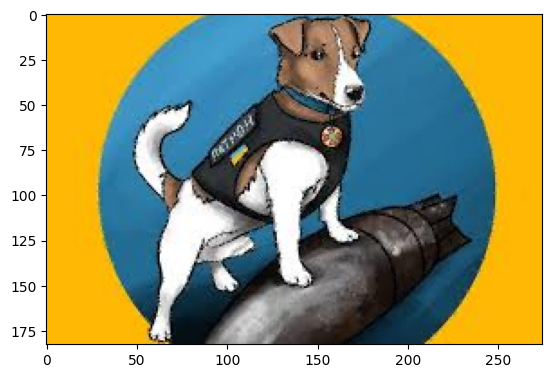

In [11]:
plt.imshow(sol)